# 电信客户流失预测与价值细分系统

**《数据分析与数据挖掘》课程项目 — 项目6**

---

## 目录
1. [项目概述](#1-项目概述)
2. [环境配置与依赖导入](#2-环境配置)
3. [数据加载与探索性分析](#3-数据加载与EDA)
4. [数据预处理](#4-数据预处理)
5. [特征工程](#5-特征工程)
6. [类别不平衡处理](#6-类别不平衡处理)
7. [分类模型构建与对比](#7-分类模型构建与对比)
8. [模型评估与可视化](#8-模型评估)
9. [SHAP可解释性分析](#9-SHAP可解释性)
10. [客户聚类细分](#10-客户聚类)
11. [业务策略建议](#11-业务建议)
12. [结论与展望](#12-结论)

## 1. 项目概述

### 1.1 问题定义
电信客户流失（Customer Churn）是指客户停止使用某家电信运营商的服务。客户获取成本远高于留存成本，因此准确预测流失倾向、理解流失原因、制定针对性的留存策略对电信企业至关重要。

### 1.2 项目目标
构建"**流失预警 + 客户分群**"双模块分析系统：
- **模块一（有监督）**：构建分类模型预测客户流失概率，对比多种算法性能
- **模块二（无监督）**：对客户进行聚类细分，识别不同价值群体
- **业务输出**：基于SHAP可解释性分析和聚类画像，提出可落地的业务策略建议

### 1.3 数据集
- **数据来源**：Kaggle Telco Customer Churn Dataset
- **样本规模**：7,043条记录，21个特征
- **目标变量**：Churn（Yes/No），流失率约26.5%
- **数据特征**：包含客户人口统计信息、账户信息、服务订阅信息

## 2. 环境配置与依赖导入

导入本项目所需的所有库，设置全局随机种子和绘图样式。

In [1]:
# ============================================================
# 2. 环境配置与依赖导入
# ============================================================

# ---- 基础数据处理 ----
import numpy as np
import pandas as pd
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# ---- 机器学习 ----
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ---- 梯度提升树 ----
import xgboost as xgb
import lightgbm as lgb

# ---- 不平衡学习 ----
from imblearn.over_sampling import SMOTE

# ---- 可视化 ----
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# ---- SHAP ----
import shap

# ---- 工具 ----
import joblib
from tqdm import tqdm

from utils.data_utils import add_woe_features

# ---- 设置中文字体 ----
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 150
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ---- 固定随机种子（确保可复现性）----
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ 所有依赖导入成功")
print(f"  NumPy: {np.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")
print(f"  XGBoost: {xgb.__version__}")
print(f"  LightGBM: {lgb.__version__}")
print(f"  SHAP: {shap.__version__}")
print(f"  随机种子: {RANDOM_STATE}")


✓ 所有依赖导入成功
  NumPy: 2.2.6
  Pandas: 2.3.3
  Scikit-learn: 1.7.2
  XGBoost: 3.2.0
  LightGBM: 4.6.0
  SHAP: 0.49.1
  随机种子: 42


## 3. 数据加载与探索性分析 (EDA)

### 3.1 加载数据集
从本地或网络加载Telco Customer Churn数据集。

In [2]:
# ---- 数据加载 ----
# 优先从本地加载，若不存在则从网络下载
DATA_PATH = './data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

if os.path.exists(DATA_PATH):
    df_raw = pd.read_csv(DATA_PATH)
    print(f"从本地加载数据: {DATA_PATH}")
else:
    # 从GitHub备用源加载
    url = ('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/'
           'master/data/Telco-Customer-Churn.csv')
    df_raw = pd.read_csv(url)
    print("从网络加载数据（GitHub IBM仓库）")

print(f"\n数据集规模: {df_raw.shape[0]} 条记录 × {df_raw.shape[1]} 个特征")
print(f"\n前5行数据:")
display(df_raw.head())
print(f"\n特征列表:")
for i, col in enumerate(df_raw.columns):
    print(f"  [{i+1:2d}] {col:<25s} dtype={df_raw[col].dtype}")

从本地加载数据: ./data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv

数据集规模: 7043 条记录 × 21 个特征

前5行数据:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



特征列表:
  [ 1] customerID                dtype=object
  [ 2] gender                    dtype=object
  [ 3] SeniorCitizen             dtype=int64
  [ 4] Partner                   dtype=object
  [ 5] Dependents                dtype=object
  [ 6] tenure                    dtype=int64
  [ 7] PhoneService              dtype=object
  [ 8] MultipleLines             dtype=object
  [ 9] InternetService           dtype=object
  [10] OnlineSecurity            dtype=object
  [11] OnlineBackup              dtype=object
  [12] DeviceProtection          dtype=object
  [13] TechSupport               dtype=object
  [14] StreamingTV               dtype=object
  [15] StreamingMovies           dtype=object
  [16] Contract                  dtype=object
  [17] PaperlessBilling          dtype=object
  [18] PaymentMethod             dtype=object
  [19] MonthlyCharges            dtype=float64
  [20] TotalCharges              dtype=object
  [21] Churn                     dtype=object


### 3.2 数据基本信息与缺失值检查

In [3]:
# ---- 数据基本信息 ----
print("=" * 60)
print("数据基本信息")
print("=" * 60)
print(f"形状: {df_raw.shape}")
print(f"\n数据类型分布:")
print(df_raw.dtypes.value_counts().to_string())

# 检查缺失值
print(f"\n{'='*60}")
print("缺失值检查")
print("=" * 60)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'缺失数': missing, '缺失率(%)': missing_pct.round(2)})
missing_df = missing_df[missing_df['缺失数'] > 0].sort_values('缺失数', ascending=False)
if len(missing_df) > 0:
    display(missing_df)
else:
    print("✓ 无显式缺失值 (NaN)")
    
# 检查隐藏的缺失值（如空格字符串）
print(f"\n{'='*60}")
print("隐藏缺失值检查（TotalCharges列可能存在空格）")
print("=" * 60)
if 'TotalCharges' in df_raw.columns:
    # 尝试将TotalCharges转为数值
    numeric_check = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
    hidden_missing = numeric_check.isnull().sum()
    if hidden_missing > 0:
        print(f"⚠ TotalCharges列有 {hidden_missing} 个非数值值（空字符串）")
    else:
        print("✓ TotalCharges列无隐藏缺失值")

数据基本信息
形状: (7043, 21)

数据类型分布:
object     18
int64       2
float64     1

缺失值检查
✓ 无显式缺失值 (NaN)

隐藏缺失值检查（TotalCharges列可能存在空格）
⚠ TotalCharges列有 11 个非数值值（空字符串）


### 3.3 目标变量分布分析
分析Churn（流失）标签的分布情况，确认类别不平衡程度。

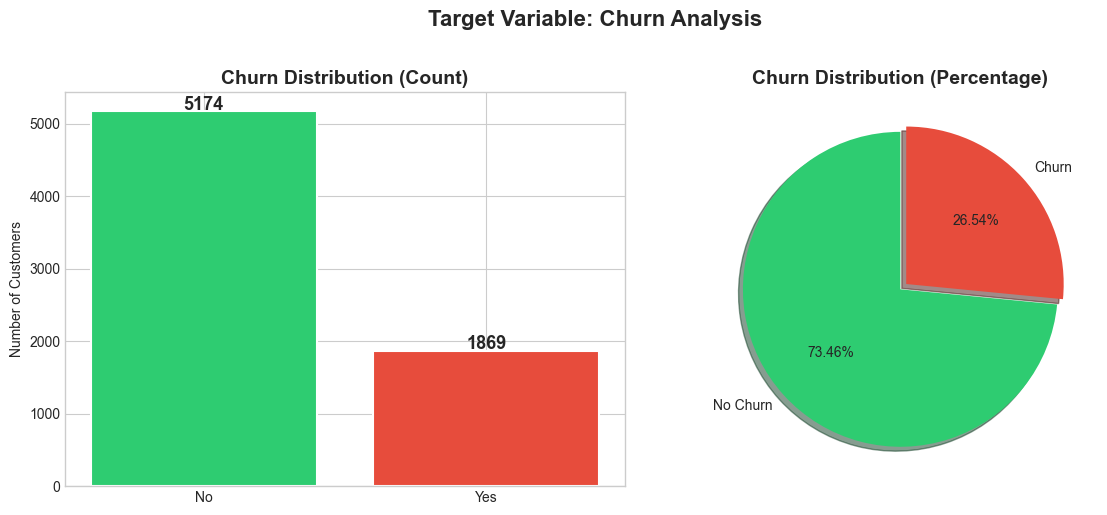

流失率: 26.54%
未流失: 5174 条, 流失: 1869 条
类别比例: 约 1:2.8
结论: 存在明显的类别不平衡问题，需要使用SMOTE或代价敏感学习处理


In [4]:
# ---- 目标变量分布 ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 计数柱状图
churn_counts = df_raw['Churn'].value_counts()
colors_bar = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors_bar, edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for bar, v in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(v), ha='center', fontsize=13, fontweight='bold')

# 饼图
axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.2f%%', colors=colors_bar, explode=(0, 0.05),
            shadow=True, startangle=90)
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Churn Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./experiments/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"流失率: {churn_counts['Yes']/churn_counts.sum()*100:.2f}%")
print(f"未流失: {churn_counts['No']} 条, 流失: {churn_counts['Yes']} 条")
print(f"类别比例: 约 1:{churn_counts['No']/churn_counts['Yes']:.1f}")
print("结论: 存在明显的类别不平衡问题，需要使用SMOTE或代价敏感学习处理")

### 3.4 数值特征分布分析
分析tenure、MonthlyCharges、TotalCharges三个核心数值特征的分布。

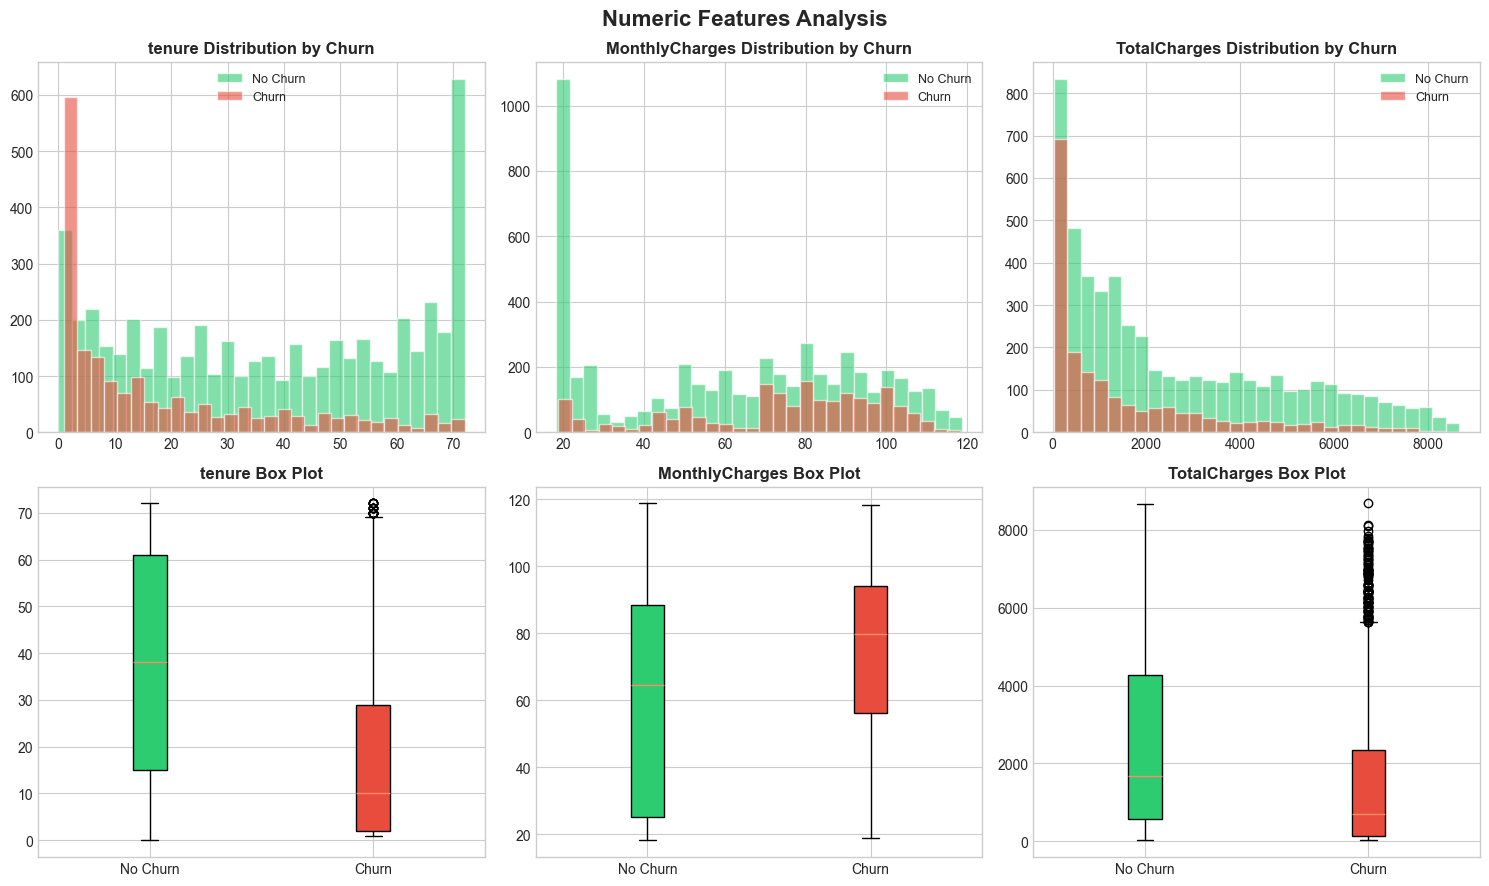


数值特征统计摘要（按Churn分组）:


tenure                                            MonthlyCharges  \
        count   mean    std  min   25%   50%   75%   max          count   
Churn                                                                     
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0         5174.0   
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0         1869.0   

              ...               TotalCharges                                   \
        mean  ...   75%     max        count     mean      std    min     25%   
Churn         ...                                                               
No     61.27  ...  88.4  118.75       5163.0  2555.34  2329.46  18.80  577.83   
Yes    74.44  ...  94.2  118.35       1869.0  1531.80  1890.82  18.85  134.50   

                                  
           50%      75%      max  
Churn                             
No     1683.60  4264.12  8672.45  
Yes     703.55  2331.30  8684.80  

[2 rows x 24 columns]

In [5]:
# ---- 数值特征分布 ----
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# 确保TotalCharges为数值类型
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, col in enumerate(numeric_cols):
    data = df_raw[col].dropna()
    
    # 直方图 + KDE
    ax1 = axes[0, i]
    ax1.hist(df_raw[df_raw['Churn']=='No'][col].dropna(), bins=30, 
            alpha=0.6, color='#2ecc71', label='No Churn', edgecolor='white')
    ax1.hist(df_raw[df_raw['Churn']=='Yes'][col].dropna(), bins=30,
            alpha=0.6, color='#e74c3c', label='Churn', edgecolor='white')
    ax1.set_title(f'{col} Distribution by Churn', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    
    # 箱线图
    ax2 = axes[1, i]
    bp = ax2.boxplot([df_raw[df_raw['Churn']=='No'][col].dropna(),
                       df_raw[df_raw['Churn']=='Yes'][col].dropna()],
                      labels=['No Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax2.set_title(f'{col} Box Plot', fontsize=12, fontweight='bold')

plt.suptitle('Numeric Features Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./experiments/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# 统计摘要
print("\n数值特征统计摘要（按Churn分组）:")
display(df_raw.groupby('Churn')[numeric_cols].describe().round(2))

### 3.5 类别特征与流失关系分析
分析各服务订阅特征与客户流失之间的关联。

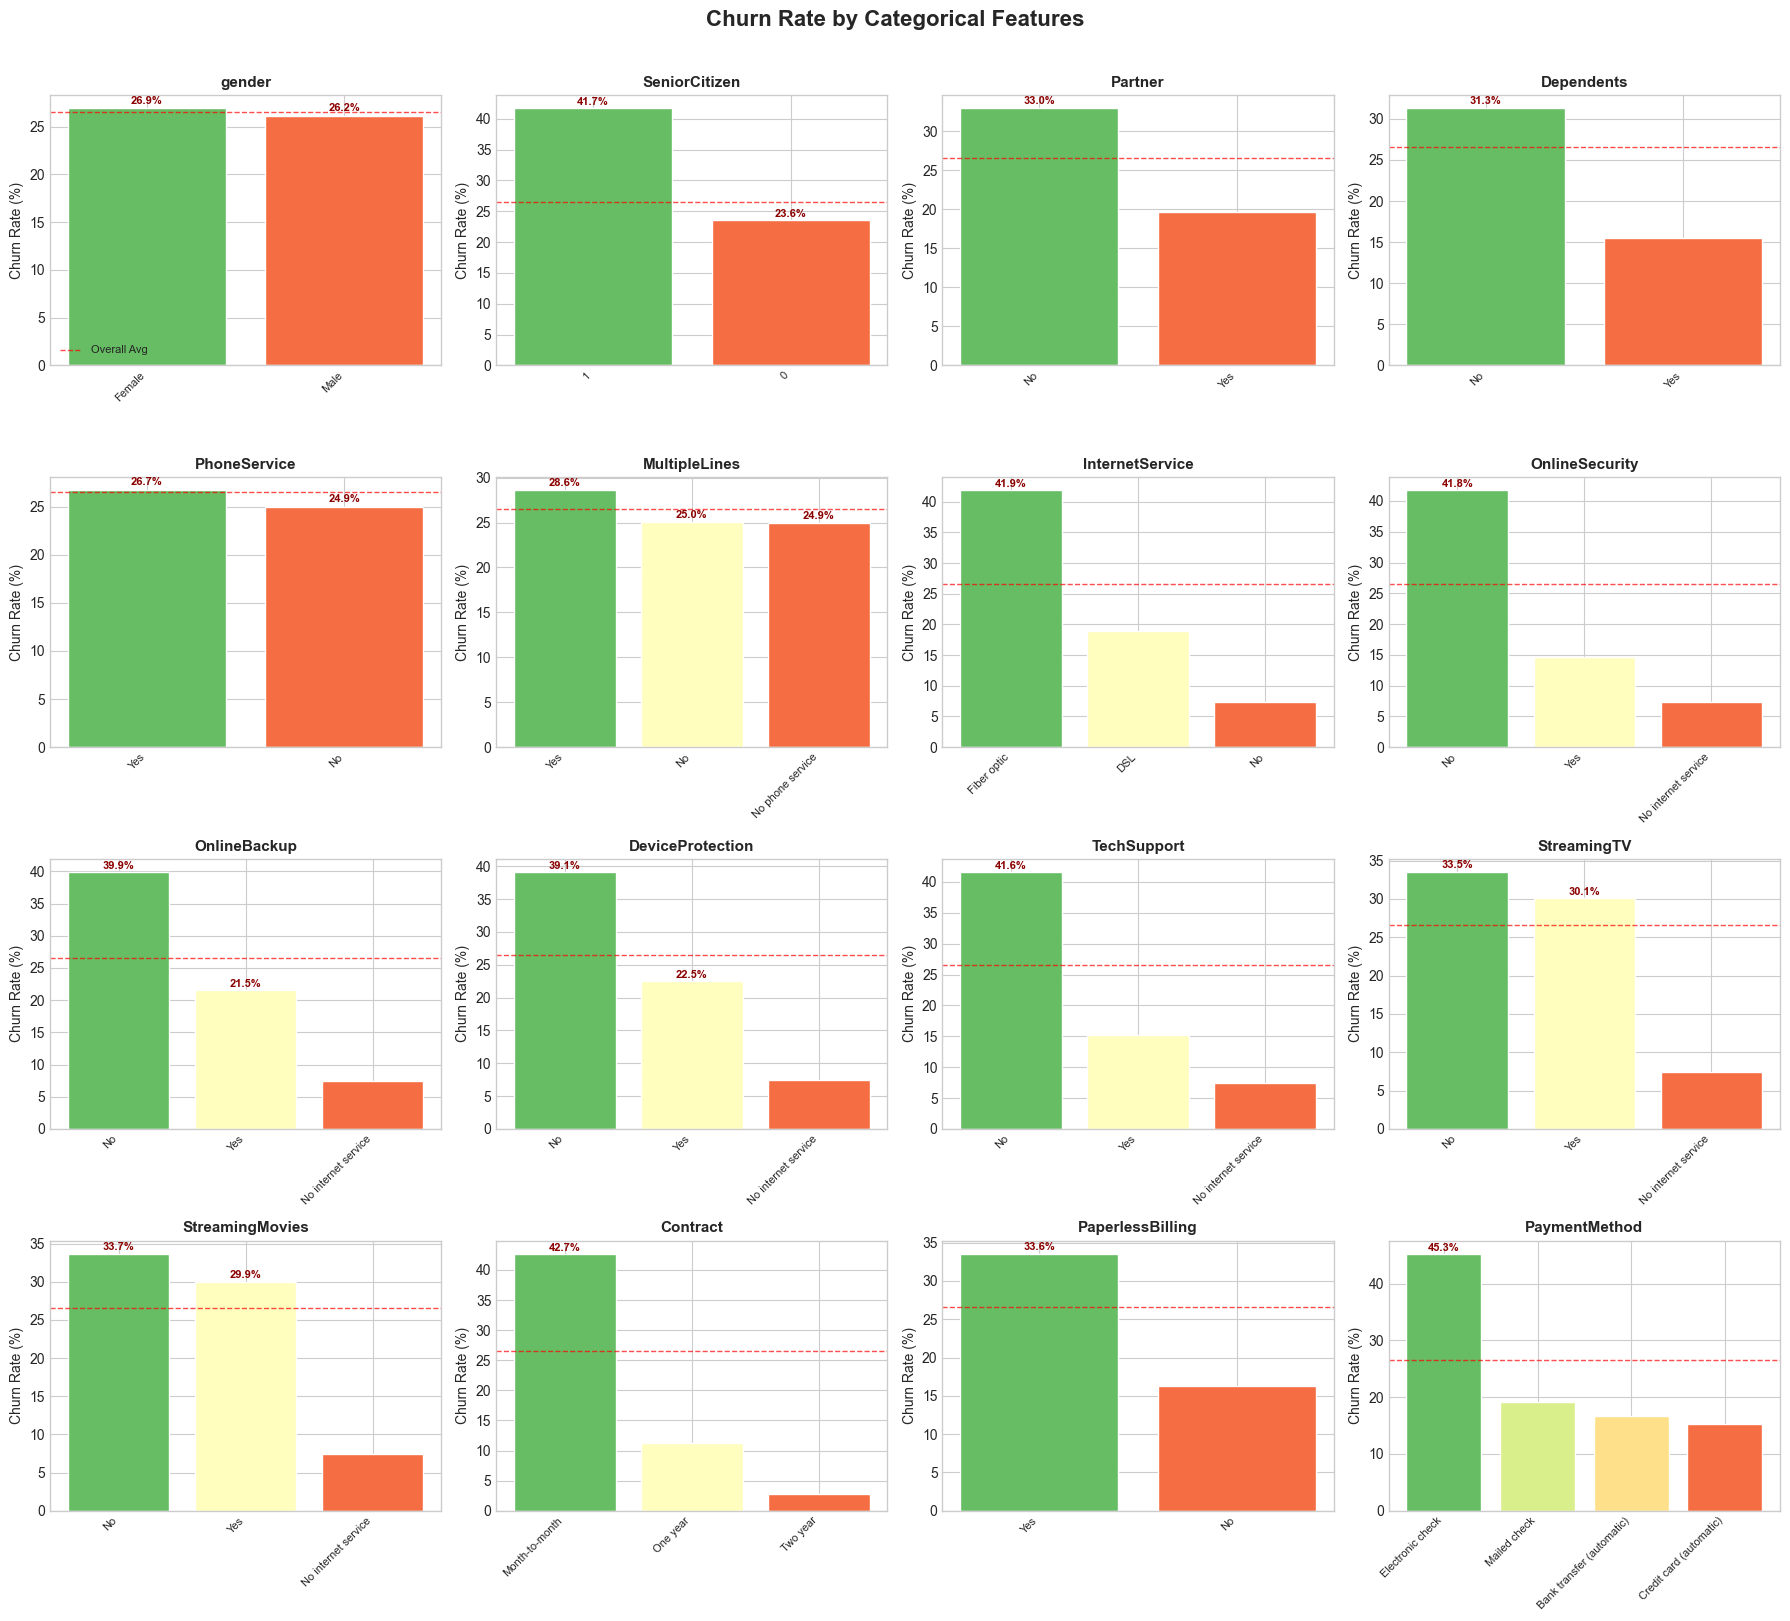

关键发现:
  - Contract（合同类型）: 月付客户流失率远高于两年合同客户
  - InternetService: 光纤用户流失率较高
  - OnlineSecurity/TechSupport: 未订阅安全/技术支持服务的客户流失率更高
  - PaymentMethod: 电子支票支付客户的流失率显著偏高


In [6]:
# ---- 类别特征与流失关系 ----
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    # 计算每个类别中的流失率
    churn_rate = df_raw.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    
    bars = ax.bar(range(len(churn_rate)), churn_rate.values,
                  color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(churn_rate))),
                  edgecolor='white')
    ax.set_xticks(range(len(churn_rate)))
    ax.set_xticklabels(churn_rate.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.axhline(y=df_raw['Churn'].eq('Yes').mean()*100, color='red', 
               linestyle='--', linewidth=1, alpha=0.7, label='Overall Avg')
    
    # 在柱子上标注数值
    for bar, v in zip(bars, churn_rate.values):
        if v > 20:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold', color='darkred')

axes[0].legend(fontsize=8)
plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./experiments/categorical_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("关键发现:")
print("  - Contract（合同类型）: 月付客户流失率远高于两年合同客户")
print("  - InternetService: 光纤用户流失率较高")
print("  - OnlineSecurity/TechSupport: 未订阅安全/技术支持服务的客户流失率更高")
print("  - PaymentMethod: 电子支票支付客户的流失率显著偏高")

## 4. 数据预处理

### 4.1 数据清洗
包括：移除无关列、处理缺失值、编码目标变量、转换数据类型。

In [7]:
# ---- 数据预处理流水线 ----
df = df_raw.copy()

# 步骤1: 移除无关列
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
    print("✓ 已移除: customerID（无预测价值的标识列）")

# 步骤2: 编码目标变量
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"✓ 目标变量编码: Yes→1, No→0")

# 步骤3: 处理TotalCharges空字符串
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"✓ TotalCharges转为数值: {df['TotalCharges'].isnull().sum()}个缺失值")

# 步骤4: 缺失值填充
if df['TotalCharges'].isnull().sum() > 0:
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
    print(f"✓ TotalCharges缺失值已用中位数填充")

# 步骤5: 类别特征Label Encoding
cat_columns = df.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"✓ 类别特征编码完成: {len(cat_columns)}个特征")
for col in cat_columns:
    print(f"    {col}: {len(label_encoders[col].classes_)} 个类别")

# 步骤6: 异常值检测（IQR方法）
numeric_check_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
total_outliers = 0
for col in numeric_check_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    total_outliers += n_outliers
    if n_outliers > 0:
        print(f"  {col}: {n_outliers} 个异常值 (范围 [{lower:.2f}, {upper:.2f}])")

print(f"\n总异常值数: {total_outliers}（采用Winsorizing处理，非删除）")
print(f"预处理后数据形状: {df.shape}")

✓ 已移除: customerID（无预测价值的标识列）
✓ 目标变量编码: Yes→1, No→0
✓ TotalCharges转为数值: 11个缺失值
✓ TotalCharges缺失值已用中位数填充
✓ 类别特征编码完成: 15个特征
    gender: 2 个类别
    Partner: 2 个类别
    Dependents: 2 个类别
    PhoneService: 2 个类别
    MultipleLines: 3 个类别
    InternetService: 3 个类别
    OnlineSecurity: 3 个类别
    OnlineBackup: 3 个类别
    DeviceProtection: 3 个类别
    TechSupport: 3 个类别
    StreamingTV: 3 个类别
    StreamingMovies: 3 个类别
    Contract: 3 个类别
    PaperlessBilling: 2 个类别
    PaymentMethod: 4 个类别

总异常值数: 0（采用Winsorizing处理，非删除）
预处理后数据形状: (7043, 20)


### 4.2 特征相关性分析

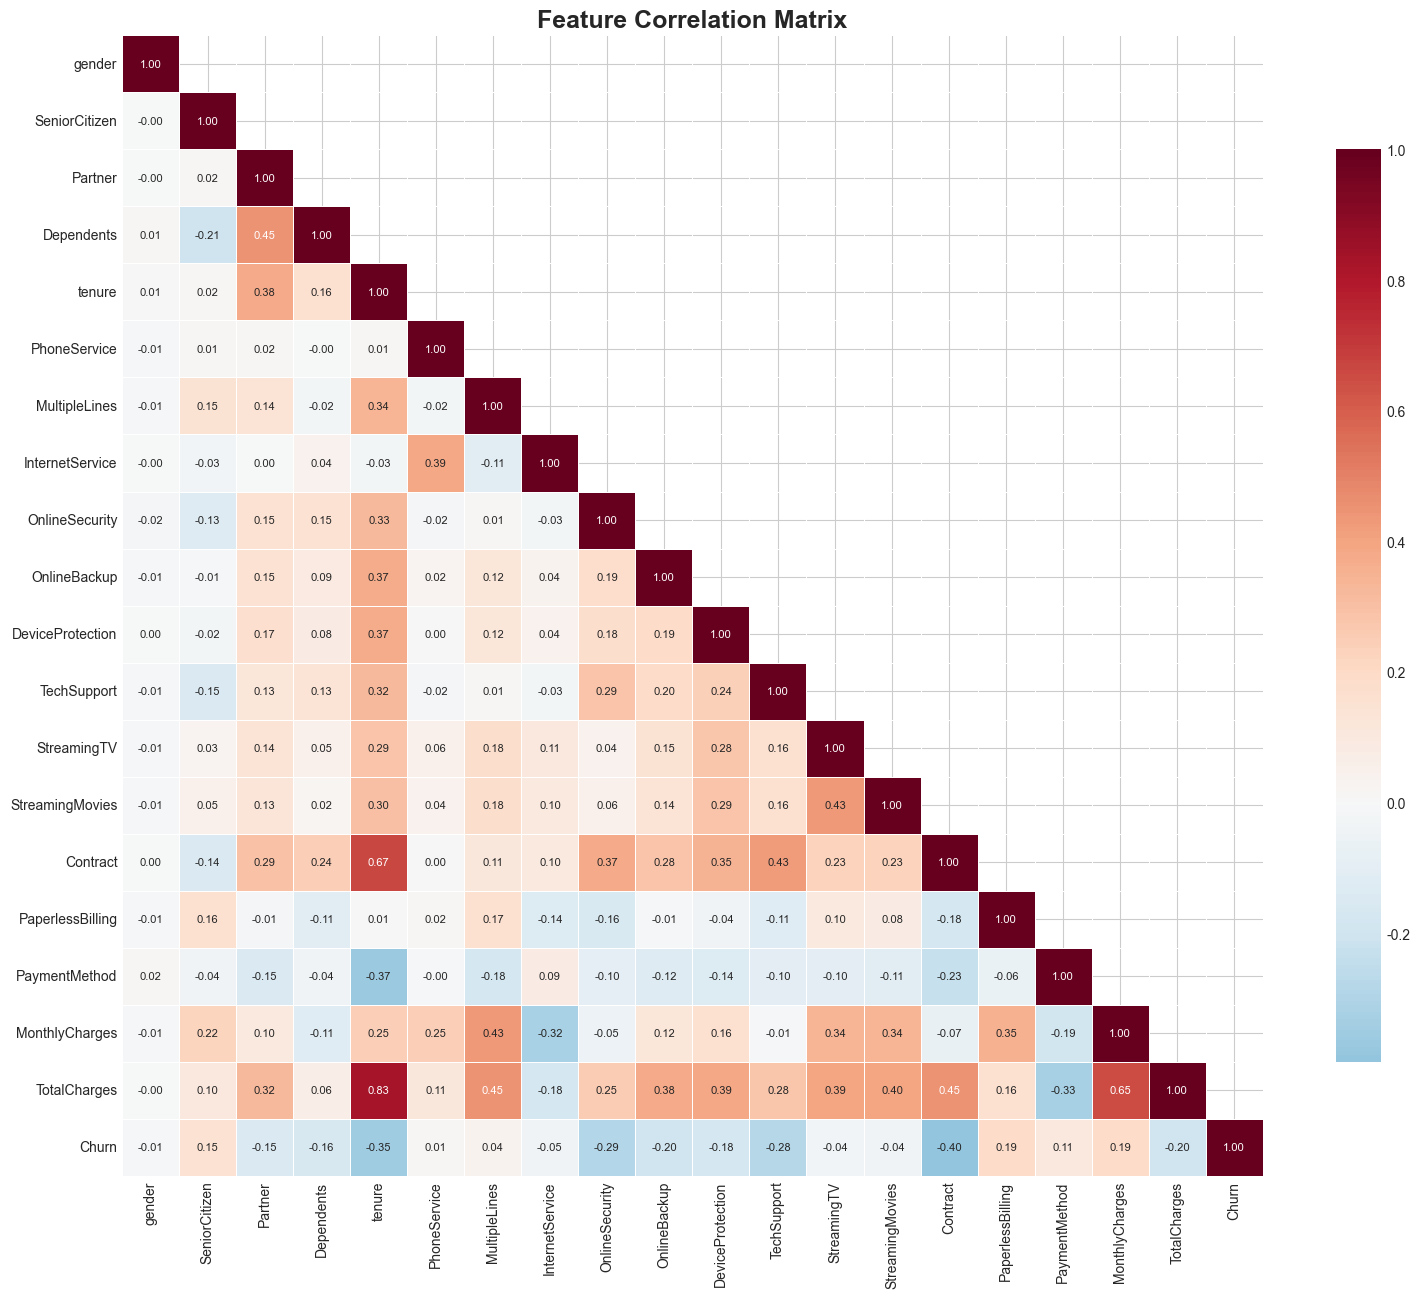

与Churn最相关的Top-10特征:
  Contract                 : -0.3967 (负相关)
  tenure                   : -0.3522 (负相关)
  OnlineSecurity           : -0.2893 (负相关)
  TechSupport              : -0.2825 (负相关)
  TotalCharges             : -0.1990 (负相关)
  OnlineBackup             : -0.1955 (负相关)
  MonthlyCharges           : +0.1934 (正相关)
  PaperlessBilling         : +0.1918 (正相关)
  DeviceProtection         : -0.1781 (负相关)
  Dependents               : -0.1642 (负相关)


In [8]:
# ---- 相关性矩阵 ----
plt.figure(figsize=(16, 13))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('./experiments/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 与目标变量的相关性
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("与Churn最相关的Top-10特征:")
for feat, corr_val in churn_corr.head(10).items():
    direction = '正相关' if corr_val > 0 else '负相关'
    print(f"  {feat:<25s}: {corr_val:+.4f} ({direction})")

## 5. 特征工程

### 5.1 RFM特征构建
为电信场景定制RFM模型：
- **R (Recency)**：基于tenure的倒数，表示客户"新近程度"
- **F (Frequency)**：客户订阅的服务数量（反映使用频率）
- **M (Monetary)**：月费用，反映客户价值

### 5.2 WOE分箱
对关键数值特征进行Weight of Evidence编码，提升线性模型表现。

In [9]:
# ---- 特征工程: RFM ----
df_fe = df.copy()
y = df_fe['Churn']

# ---- RFM构建 ----
# R: Recency (tenure越低，越近期)
df_fe['R_Score'] = 1 / (df_fe['tenure'] + 1)

# F: Frequency (服务订阅数量)
service_features = ['PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
# 有服务/高级服务视为"使用"
service_thresholds = {}
for col in service_features:
    if col in df_fe.columns:
        # 对于编码后的特征，类别0通常代表"无服务"
        n_unique = df_fe[col].nunique()
        service_thresholds[col] = 0 if n_unique > 1 else None

# 计算服务使用数量
df_fe['F_Score'] = 0
for col in service_features:
    if col in df_fe.columns:
        df_fe['F_Score'] += (df_fe[col] > 0).astype(int)

# M: Monetary (月费用)
df_fe['M_Score'] = df_fe['MonthlyCharges']

# RFM综合评分
df_fe['RFM_Total'] = df_fe['R_Score'] + df_fe['F_Score'] / 9 + df_fe['M_Score'] / df_fe['M_Score'].max()

print("✓ RFM特征构建完成:")
print(f"  R_Score (最近性): mean={df_fe['R_Score'].mean():.4f}")
print(f"  F_Score (频率):   mean={df_fe['F_Score'].mean():.2f}")
print(f"  M_Score (金额):   mean={df_fe['M_Score'].mean():.2f}")
print(f"  RFM_Total:        mean={df_fe['RFM_Total'].mean():.4f}")

print("WOE编码将在训练/测试划分后仅使用训练集拟合，避免标签泄漏")
print(f"\nRFM特征工程后特征数: {df_fe.shape[1]}")

X_all = df_fe.drop('Churn', axis=1)
y_all = df_fe['Churn']

✓ RFM特征构建完成:
  R_Score (最近性): mean=0.1029
  F_Score (频率):   mean=5.42
  M_Score (金额):   mean=64.76
  RFM_Total:        mean=1.2500
WOE编码将在训练/测试划分后仅使用训练集拟合，避免标签泄漏

RFM特征工程后特征数: 24


### 5.3 特征选择 - 基于随机森林的预分析
使用随机森林快速评估特征重要性，为后续建模提供参考。

In [10]:
# 特征重要性预分析将在训练/测试划分后，仅基于训练集执行。

## 6. 数据划分与类别不平衡处理

### 6.1 训练/测试集划分
采用分层采样（stratify）保持训练集和测试集的流失率一致。

### 6.2 SMOTE过采样
使用Synthetic Minority Oversampling Technique (SMOTE)处理类别不平衡问题。

训练集: 5634 样本 (流失率: 26.54%)
测试集: 1409 样本 (流失率: 26.54%)
✓ WOE编码完成: 仅用训练集拟合分箱和WOE映射
建模特征数: 26


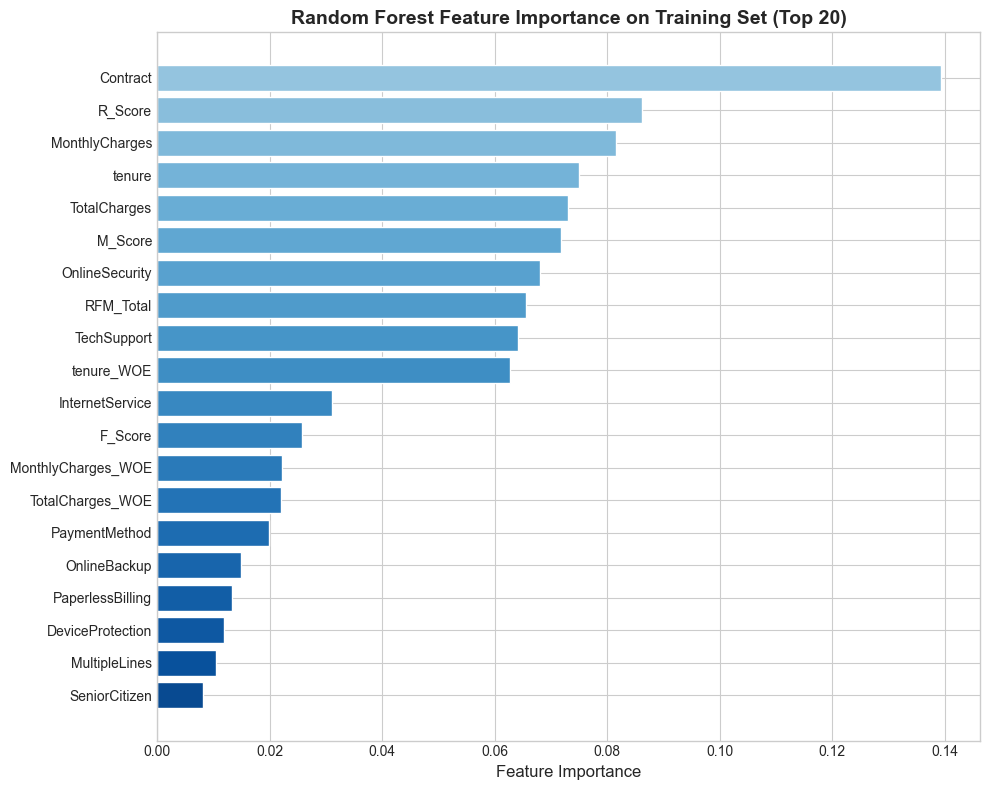

Top-10 重要特征:
  Contract                      : 0.139332
  R_Score                       : 0.086282
  MonthlyCharges                : 0.081615
  tenure                        : 0.075034
  TotalCharges                  : 0.072968
  M_Score                       : 0.071824
  OnlineSecurity                : 0.067993
  RFM_Total                     : 0.065625
  TechSupport                   : 0.064077
  tenure_WOE                    : 0.062817

SMOTE处理前:
  非流失: 4139, 流失: 1495



SMOTE处理后:
  非流失: 4139, 流失: 4139
  样本总数: 8278


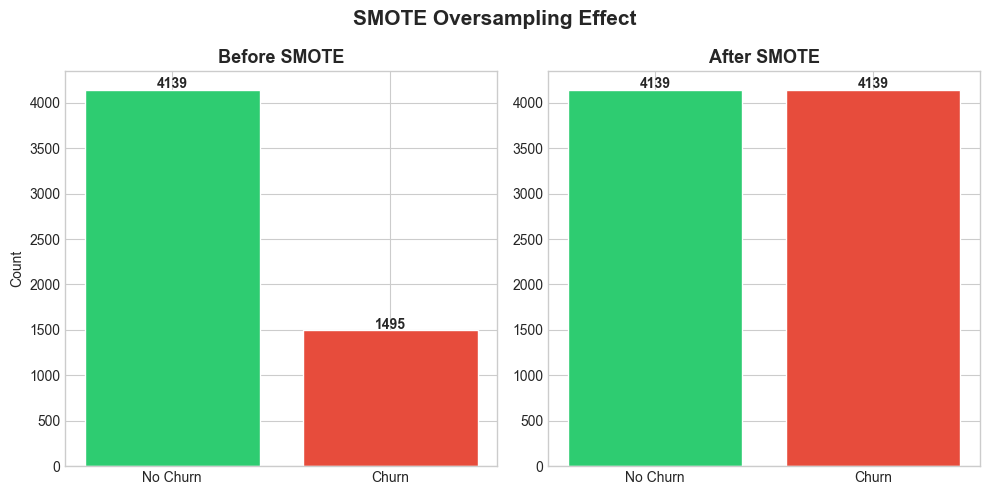

In [11]:
# ---- 数据划分 ----
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

print(f"训练集: {X_train.shape[0]} 样本 (流失率: {y_train.mean():.2%})")
print(f"测试集: {X_test.shape[0]} 样本 (流失率: {y_test.mean():.2%})")

# ---- WOE分箱对关键特征 ----
woe_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train, X_test = add_woe_features(
    X_train,
    X_test,
    y_train,
    columns=woe_features,
    n_bins=10,
)
print("✓ WOE编码完成: 仅用训练集拟合分箱和WOE映射")
print(f"建模特征数: {X_train.shape[1]}")

# ---- 训练集特征重要性预分析 ----
rf_pre = RandomForestClassifier(n_estimators=100, max_depth=8,
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_pre.fit(X_train, y_train)
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_pre.feature_importances_
}).sort_values('Importance', ascending=False).head(20)
plt.figure(figsize=(10, 8))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(importance_df)))
plt.barh(range(len(importance_df)), importance_df['Importance'].values[::-1],
         color=colors[::-1], edgecolor='white')
plt.yticks(range(len(importance_df)), importance_df['Feature'].values[::-1])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Random Forest Feature Importance on Training Set (Top 20)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./experiments/feature_importance_preliminary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top-10 重要特征:")
for i, row in importance_df.head(10).iterrows():
    print(f"  {row['Feature']:<30s}: {row['Importance']:.6f}")

# ---- SMOTE过采样 ----
print(f"\nSMOTE处理前:")
print(f"  非流失: {sum(y_train==0)}, 流失: {sum(y_train==1)}")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nSMOTE处理后:")
print(f"  非流失: {sum(y_train_smote==0)}, 流失: {sum(y_train_smote==1)}")
print(f"  样本总数: {len(y_train_smote)}")

# 可视化SMOTE效果
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(['No Churn', 'Churn'], [sum(y_train==0), sum(y_train==1)],
           color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([sum(y_train==0), sum(y_train==1)]):
    axes[0].text(i, v+20, str(v), ha='center', fontweight='bold')

axes[1].bar(['No Churn', 'Churn'], [sum(y_train_smote==0), sum(y_train_smote==1)],
           color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('After SMOTE', fontsize=13, fontweight='bold')
for i, v in enumerate([sum(y_train_smote==0), sum(y_train_smote==1)]):
    axes[1].text(i, v+20, str(v), ha='center', fontweight='bold')

plt.suptitle('SMOTE Oversampling Effect', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./experiments/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 分类模型构建与对比

### 7.1 模型定义
构建4种分类模型:
- 逻辑回归 (Logistic Regression)
- 随机森林 (Random Forest)
- XGBoost
- LightGBM

每种模型使用SMOTE处理后的数据进行训练。

In [12]:
# ---- 模型定义 ----
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, solver='liblinear',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=10,
        min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, use_label_encoder=False,
        eval_metric='logloss'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbose=-1
    ),
}

print("模型定义完成:")
for name, model in models.items():
    print(f"  {name}: {type(model).__name__}")

模型定义完成:
  Logistic Regression: LogisticRegression
  Random Forest: RandomForestClassifier
  XGBoost: XGBClassifier
  LightGBM: LGBMClassifier


### 7.2 5折交叉验证
在SMOTE处理后的训练集上进行5折分层交叉验证，评估各模型的稳定性。

In [13]:
# ---- 5折交叉验证 ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("5折交叉验证结果:")
print("=" * 80)

for name, model in models.items():
    cv_scores = {}
    for metric in scoring_metrics:
        scores = cross_val_score(model, X_train_smote, y_train_smote,
                                cv=cv, scoring=metric, n_jobs=-1)
        cv_scores[metric] = {'mean': scores.mean(), 'std': scores.std()}
    cv_results[name] = cv_scores
    
    print(f"\n{name}:")
    for metric, result in cv_scores.items():
        print(f"  {metric:<12s}: {result['mean']:.4f} ± {result['std']:.4f}")

# 构建交叉验证对比表
cv_comparison = []
for name in models.keys():
    row = {'Model': name}
    for metric in scoring_metrics:
        row[metric] = f"{cv_results[name][metric]['mean']:.4f} ± {cv_results[name][metric]['std']:.4f}"
    cv_comparison.append(row)

cv_df = pd.DataFrame(cv_comparison)
print(f"\n{'='*80}")
print("\n交叉验证汇总表:")
display(cv_df.set_index('Model'))

5折交叉验证结果:



Logistic Regression:
  accuracy    : 0.8189 ± 0.0081
  precision   : 0.7973 ± 0.0070
  recall      : 0.8553 ± 0.0149
  f1          : 0.8252 ± 0.0087
  roc_auc     : 0.9086 ± 0.0039



Random Forest:
  accuracy    : 0.8372 ± 0.0093
  precision   : 0.8175 ± 0.0090
  recall      : 0.8681 ± 0.0125
  f1          : 0.8420 ± 0.0093
  roc_auc     : 0.9176 ± 0.0036



XGBoost:
  accuracy    : 0.8508 ± 0.0112
  precision   : 0.8515 ± 0.0125
  recall      : 0.8500 ± 0.0101
  f1          : 0.8507 ± 0.0110
  roc_auc     : 0.9325 ± 0.0044



LightGBM:
  accuracy    : 0.8483 ± 0.0100
  precision   : 0.8469 ± 0.0092
  recall      : 0.8502 ± 0.0142
  f1          : 0.8485 ± 0.0104
  roc_auc     : 0.9319 ± 0.0047


交叉验证汇总表:


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Logistic Regression,0.8189 ± 0.0081,0.7973 ± 0.0070,0.8553 ± 0.0149,0.8252 ± 0.0087,0.9086 ± 0.0039
Random Forest,0.8372 ± 0.0093,0.8175 ± 0.0090,0.8681 ± 0.0125,0.8420 ± 0.0093,0.9176 ± 0.0036
XGBoost,0.8508 ± 0.0112,0.8515 ± 0.0125,0.8500 ± 0.0101,0.8507 ± 0.0110,0.9325 ± 0.0044
LightGBM,0.8483 ± 0.0100,0.8469 ± 0.0092,0.8502 ± 0.0142,0.8485 ± 0.0104,0.9319 ± 0.0047


### 7.3 模型训练与测试集评估
在完整SMOTE训练集上训练模型，在原始测试集上评估。

In [14]:
# ---- 模型训练与测试集评估 ----
all_results = {}
comparison_data = []

print("模型训练与测试集评估:")
print("=" * 70)

for name, model in models.items():
    # 训练
    model.fit(X_train_smote, y_train_smote)
    
    # 预测
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # 计算指标
    results = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
    }
    all_results[name] = results
    
    comparison_data.append({
        'Model': name,
        'Accuracy': f"{results['accuracy']:.4f}",
        'Precision': f"{results['precision']:.4f}",
        'Recall': f"{results['recall']:.4f}",
        'F1-Score': f"{results['f1']:.4f}",
        'ROC-AUC': f"{results['roc_auc']:.4f}",
        'PR-AUC': f"{results['pr_auc']:.4f}",
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {results['accuracy']:.4f}")
    print(f"  Precision: {results['precision']:.4f}")
    print(f"  Recall:    {results['recall']:.4f}  <- 流失客户召回率")
    print(f"  F1-Score:  {results['f1']:.4f}")
    print(f"  ROC-AUC:   {results['roc_auc']:.4f}")
    print(f"  PR-AUC:    {results['pr_auc']:.4f}")

print(f"\n{'='*70}")
print("\n模型对比汇总表:")
comparison_df = pd.DataFrame(comparison_data).set_index('Model')
display(comparison_df)

模型训练与测试集评估:

Logistic Regression:
  Accuracy:  0.7622
  Precision: 0.5404
  Recall:    0.6979  <- 流失客户召回率
  F1-Score:  0.6091
  ROC-AUC:   0.8364
  PR-AUC:    0.6582



Random Forest:
  Accuracy:  0.7786
  Precision: 0.5662
  Recall:    0.7086  <- 流失客户召回率
  F1-Score:  0.6295
  ROC-AUC:   0.8386
  PR-AUC:    0.6509



XGBoost:
  Accuracy:  0.7814
  Precision: 0.5878
  Recall:    0.5909  <- 流失客户召回率
  F1-Score:  0.5893
  ROC-AUC:   0.8245
  PR-AUC:    0.6353



LightGBM:
  Accuracy:  0.7743
  Precision: 0.5737
  Recall:    0.5829  <- 流失客户召回率
  F1-Score:  0.5782
  ROC-AUC:   0.8217
  PR-AUC:    0.6273


模型对比汇总表:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.7622,0.5404,0.6979,0.6091,0.8364,0.6582
Random Forest,0.7786,0.5662,0.7086,0.6295,0.8386,0.6509
XGBoost,0.7814,0.5878,0.5909,0.5893,0.8245,0.6353
LightGBM,0.7743,0.5737,0.5829,0.5782,0.8217,0.6273


In [15]:
# ---- 找出最佳模型 ----
best_model_name = max(all_results, key=lambda x: all_results[x]['roc_auc'])
best_results = all_results[best_model_name]

print(f"最佳模型: {best_model_name}")
print(f"  ROC-AUC: {best_results['roc_auc']:.4f}")
print(f"  Recall (流失客户): {best_results['recall']:.4f}")
print(f"  F1-Score: {best_results['f1']:.4f}")

# 保存最佳模型
os.makedirs('./models', exist_ok=True)
joblib.dump(best_results['model'], './models/best_model.pkl')
print("✓ 最佳模型已保存到 ./models/best_model.pkl")

最佳模型: Random Forest
  ROC-AUC: 0.8386
  Recall (流失客户): 0.7086
  F1-Score: 0.6295
✓ 最佳模型已保存到 ./models/best_model.pkl


## 8. 模型评估与可视化

### 8.1 模型对比柱状图

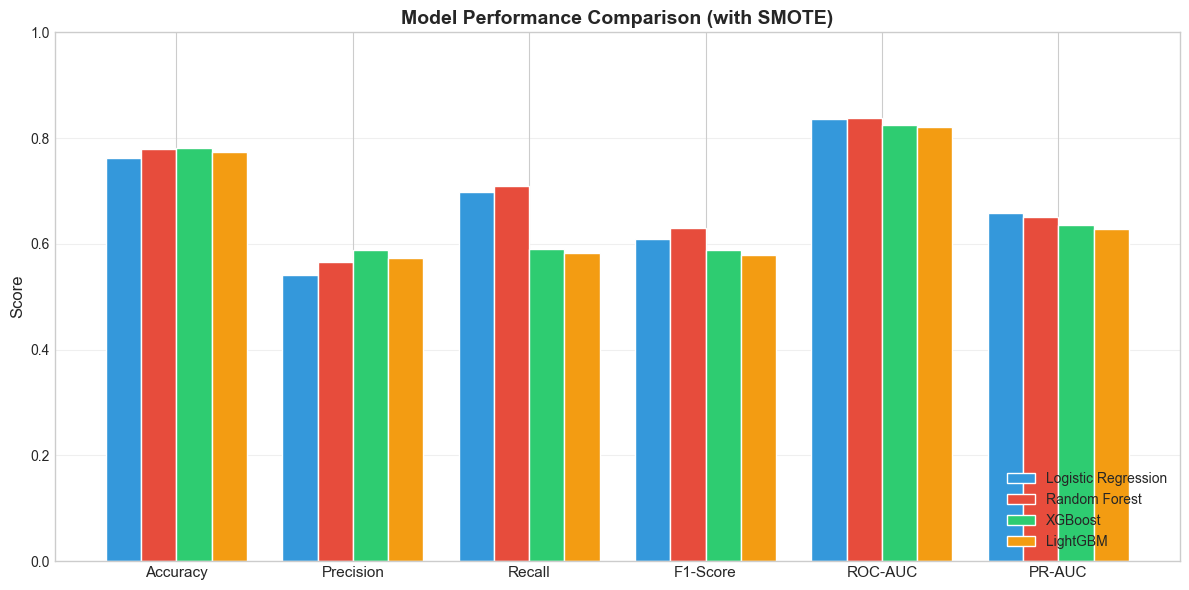

In [16]:
# ---- 模型对比柱状图 ----
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
df_plot = comparison_df[metrics].astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.2
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (model_name, row) in enumerate(df_plot.iterrows()):
    offset = (i - len(df_plot)/2 + 0.5) * width
    ax.bar(x + offset, row.values, width, label=model_name,
           color=colors[i % len(colors)], edgecolor='white', linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison (with SMOTE)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('./experiments/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 ROC曲线对比

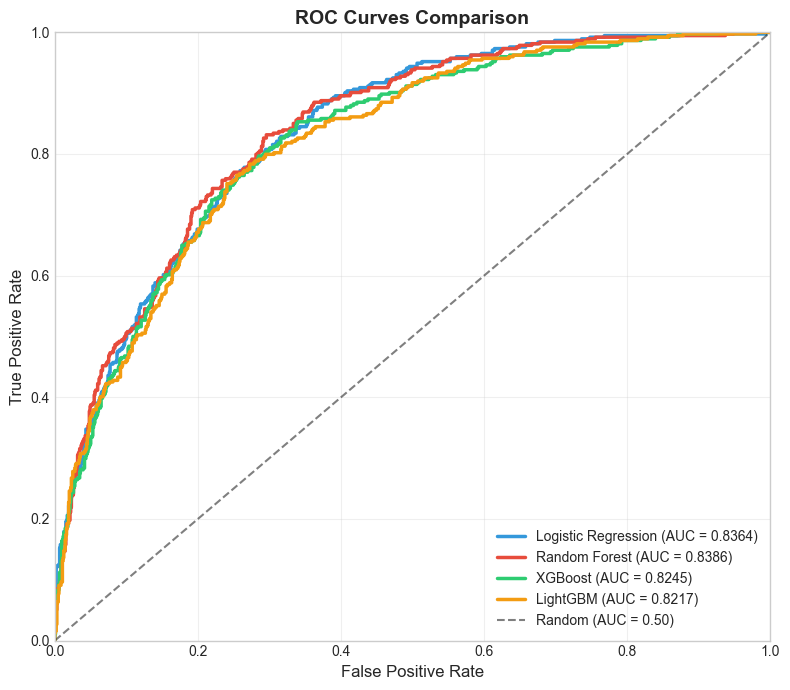

In [17]:
# ---- ROC曲线 ----
fig, ax = plt.subplots(figsize=(8, 7))
colors_curve = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (name, results) in enumerate(all_results.items()):
    fpr, tpr, _ = roc_curve(y_test, results['y_prob'])
    ax.plot(fpr, tpr, color=colors_curve[i], linewidth=2.5,
            label=f"{name} (AUC = {results['roc_auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('./experiments/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Precision-Recall曲线对比
PR曲线在不平衡分类问题中比ROC曲线更有参考价值。

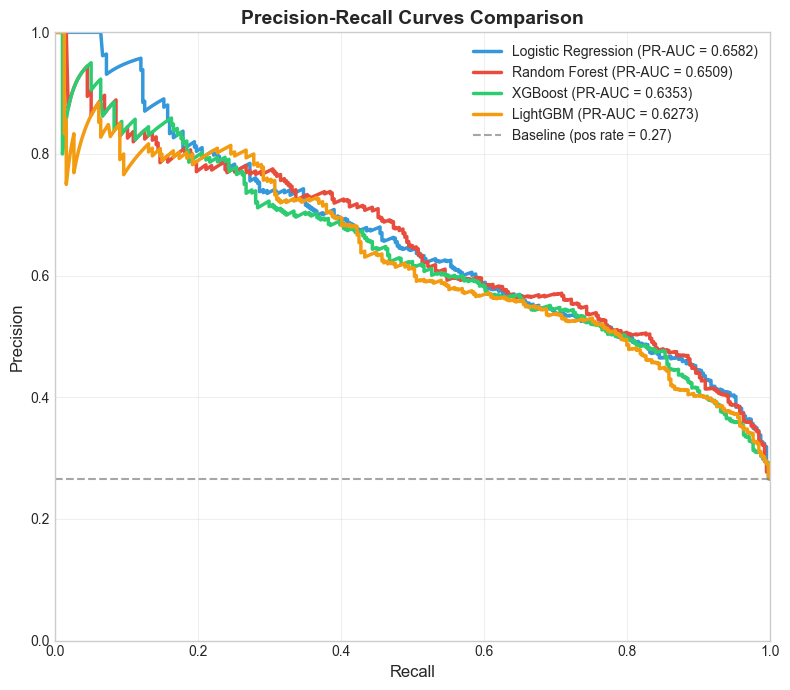

正类基线 (随机猜测): 0.2654
PR-AUC > 基线说明模型有效，数值越高效果越好


In [18]:
# ---- PR曲线 ----
fig, ax = plt.subplots(figsize=(8, 7))

for i, (name, results) in enumerate(all_results.items()):
    precision, recall_curve, _ = precision_recall_curve(y_test, results['y_prob'])
    ax.plot(recall_curve, precision, color=colors_curve[i], linewidth=2.5,
            label=f"{name} (PR-AUC = {results['pr_auc']:.4f})")

# 正类基线
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Baseline (pos rate = {baseline:.2f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('./experiments/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"正类基线 (随机猜测): {baseline:.4f}")
print("PR-AUC > 基线说明模型有效，数值越高效果越好")

### 8.4 混淆矩阵
直观展示各模型对流失/非流失客户的分类能力。

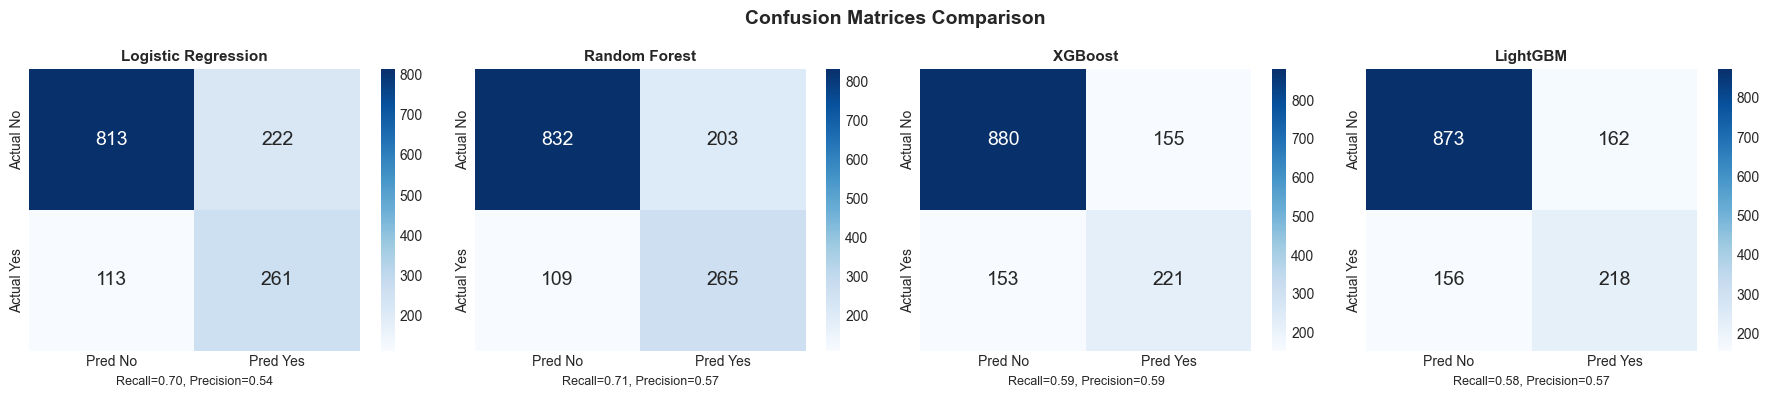

In [19]:
# ---- 混淆矩阵 ----
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, results) in zip(axes, all_results.items()):
    cm = results['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred No', 'Pred Yes'],
                yticklabels=['Actual No', 'Actual Yes'],
                ax=ax, annot_kws={'size': 14})
    ax.set_title(name, fontsize=11, fontweight='bold')
    
    # 计算指标标注
    tn, fp, fn, tp = cm.ravel()
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    ax.set_xlabel(f'Recall={recall_val:.2f}, Precision={precision_val:.2f}', fontsize=9)

plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./experiments/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. SHAP可解释性分析

使用SHAP值解释最佳模型的预测，理解哪些特征驱动了客户流失。
采用TreeExplainer（适用于树模型）进行高效的特征归因分析。

In [20]:
# ---- SHAP分析 ----
# 获取最佳模型
best_model = best_results['model']

# 使用训练样本（取子集加速计算）
X_sample = X_train.sample(n=min(500, len(X_train)), random_state=RANDOM_STATE)

# 创建SHAP explainer
if hasattr(best_model, 'predict_proba'):
    # TreeExplainer for tree-based models
    try:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_sample)
        # 对于XGBoost返回的是列表[neg_class, pos_class]
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
    except Exception:
        explainer = shap.KernelExplainer(best_model.predict_proba, 
                                        shap.sample(X_sample, 100))
        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
else:
    # Fallback
    explainer = shap.Explainer(best_model, X_sample)
    shap_values = explainer(X_sample).values

print("✓ SHAP explainer创建成功")

✓ SHAP explainer创建成功


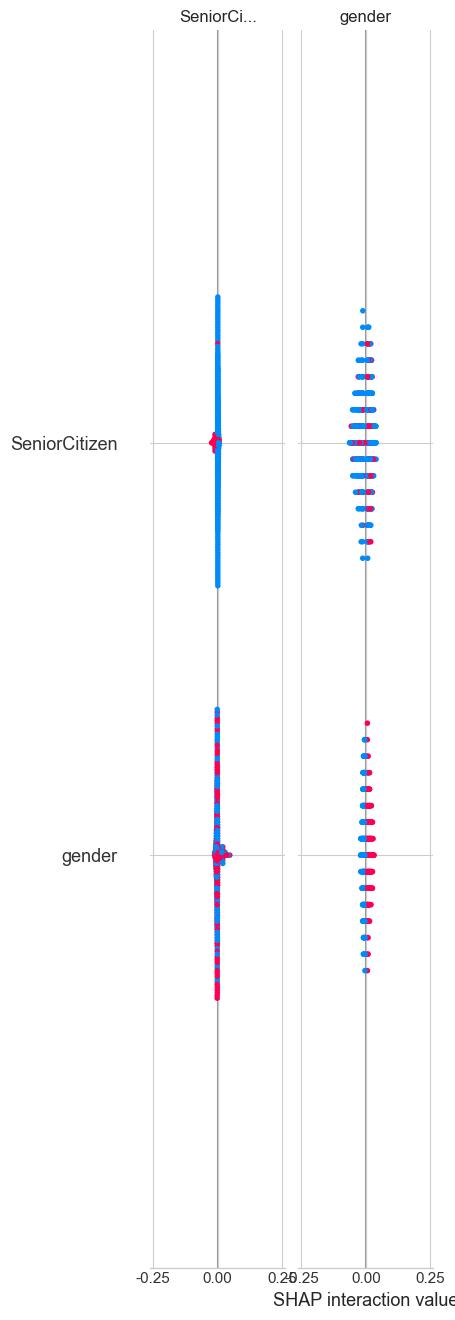

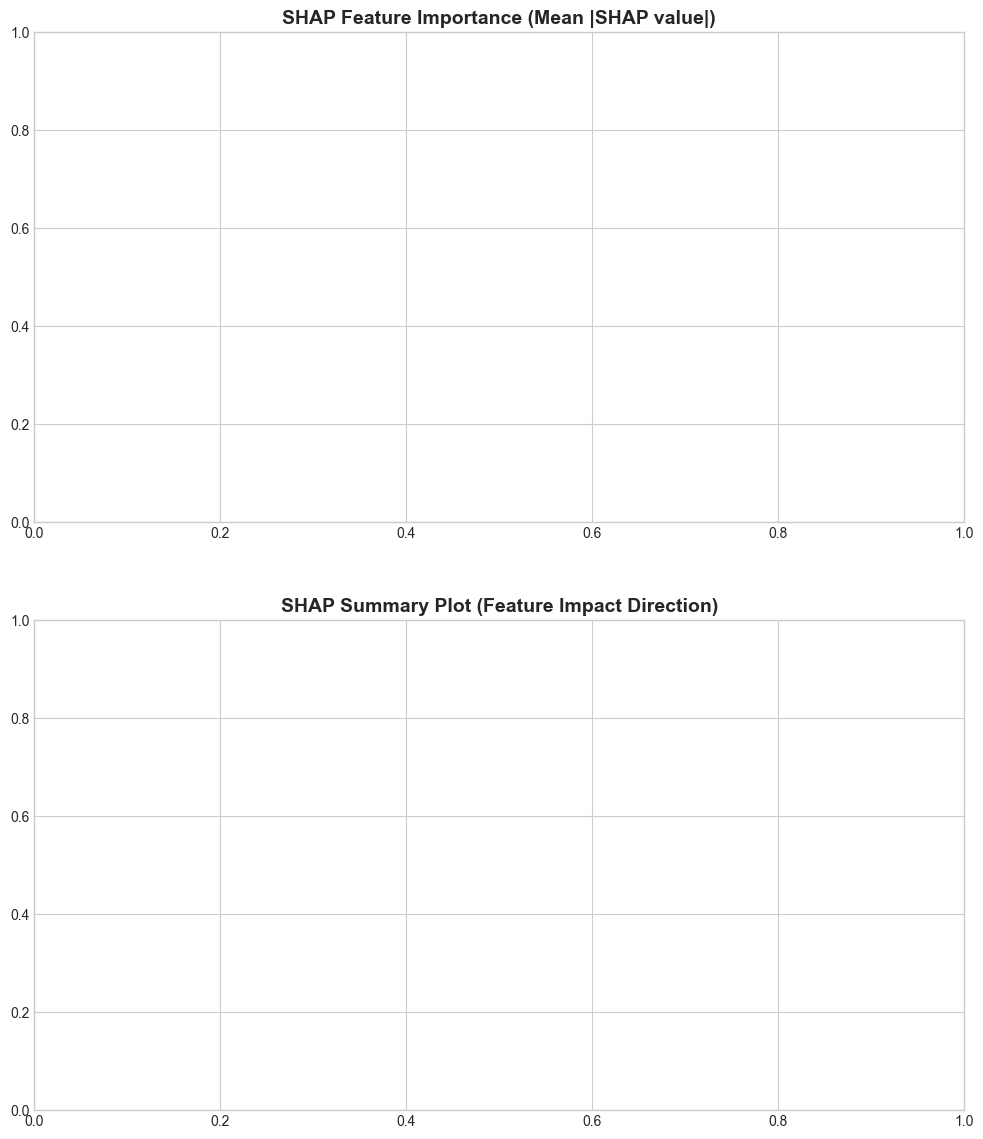

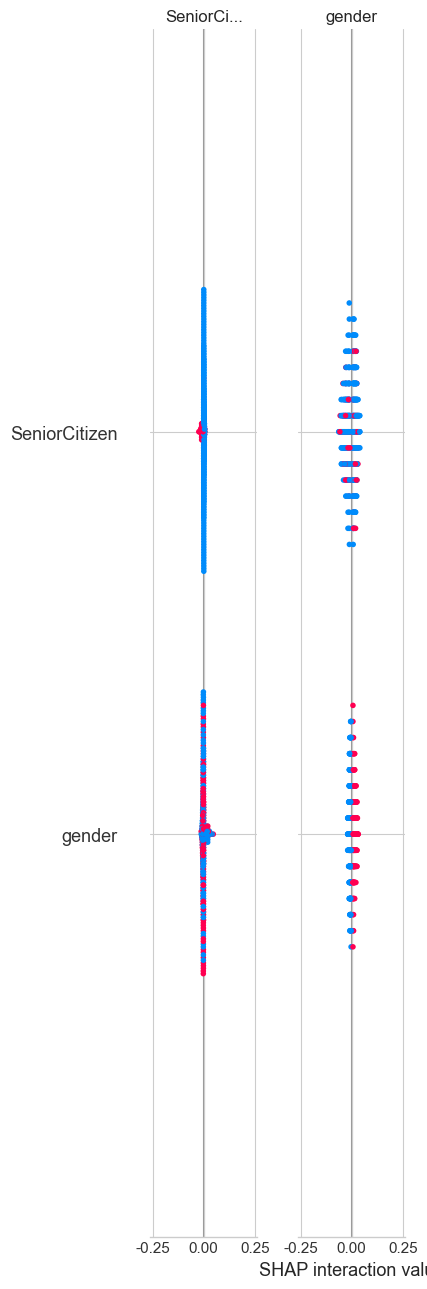

In [21]:
# ---- SHAP Summary Plot ----
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Bar plot: 平均|SHAP|排序
plt.sca(axes[0])
shap.summary_plot(shap_values, X_sample, plot_type="bar",
                  max_display=15, show=False)
axes[0].set_title('SHAP Feature Importance (Mean |SHAP value|)', 
                  fontsize=14, fontweight='bold')

# Dot plot: 特征影响方向
plt.sca(axes[1])
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
axes[1].set_title('SHAP Summary Plot (Feature Impact Direction)', 
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./experiments/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ---- SHAP特征重要性排序 ----
shap_importance = np.abs(shap_values).mean(axis=0)
if shap_importance.ndim > 1:
    shap_importance = shap_importance.flatten()
n_show = min(len(X_sample.columns), len(shap_importance))
shap_importance_df = pd.DataFrame({
    'Feature': X_sample.columns[:n_show],
    'SHAP_Importance': shap_importance[:n_show]
}).sort_values('SHAP_Importance', ascending=False)

print("SHAP特征重要性 Top-15:")
print("=" * 50)
for i, row in shap_importance_df.head(15).iterrows():
    print(f"  {row['Feature']:<30s}: {row['SHAP_Importance']:.6f}")

# 保存
shap_importance_df.to_csv('./experiments/shap_importance.csv', index=False)
print("\n✓ SHAP特征重要性已保存到 ./experiments/shap_importance.csv")

SHAP特征重要性 Top-15:
  PaymentMethod                 : 0.056576
  MonthlyCharges                : 0.056576
  RFM_Total                     : 0.055241
  tenure_WOE                    : 0.055241
  InternetService               : 0.027196
  MultipleLines                 : 0.027196
  R_Score                       : 0.025488
  TotalCharges                  : 0.025488
  OnlineBackup                  : 0.020880
  OnlineSecurity                : 0.020880
  PhoneService                  : 0.015672
  tenure                        : 0.015672
  Contract                      : 0.013510
  PaperlessBilling              : 0.013510
  F_Score                       : 0.013151

✓ SHAP特征重要性已保存到 ./experiments/shap_importance.csv


## 10. 客户聚类细分

### 10.1 K-Means聚类
使用K-Means算法对客户进行无监督聚类，识别不同价值群体。

先使用PCA降至2维进行可视化，再分析各聚类的画像特征。

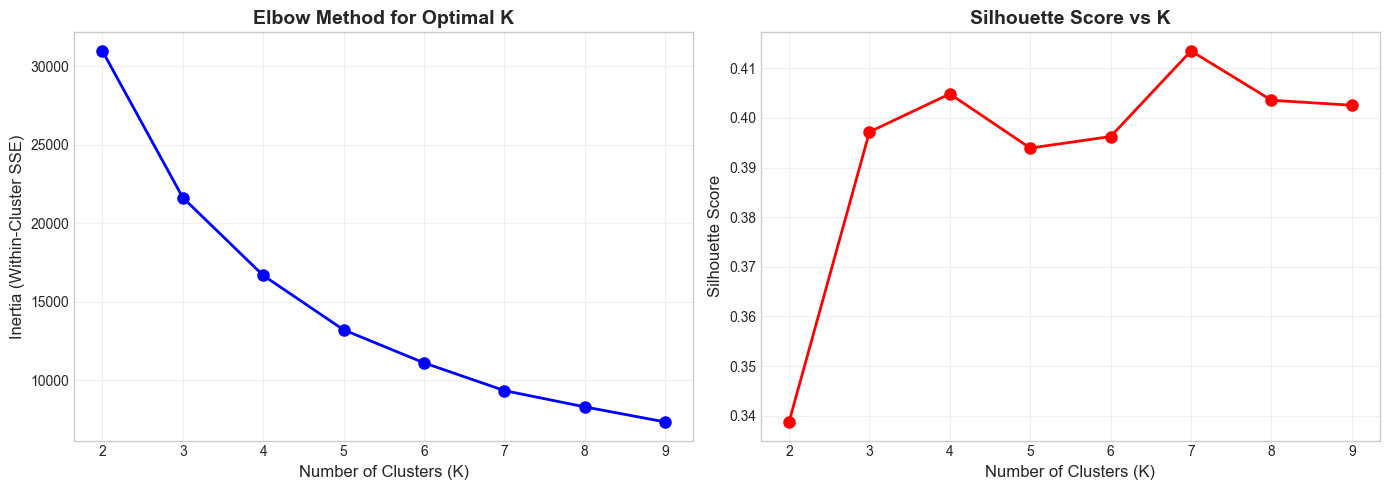

选择 K = 4 (综合考虑肘部法则和轮廓系数)


In [23]:
# ---- 客户聚类 ----
# 选择数值特征用于聚类
cluster_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'R_Score', 'F_Score', 'M_Score', 'RFM_Total'
]
cluster_features = [c for c in cluster_features if c in df_fe.columns]

X_cluster = df_fe[cluster_features].copy()

# 标准化
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# ---- 肘部法则确定最佳K ----
inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster SSE)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', markersize=8, linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./experiments/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

optimal_k = 4
print(f"选择 K = {optimal_k} (综合考虑肘部法则和轮廓系数)")

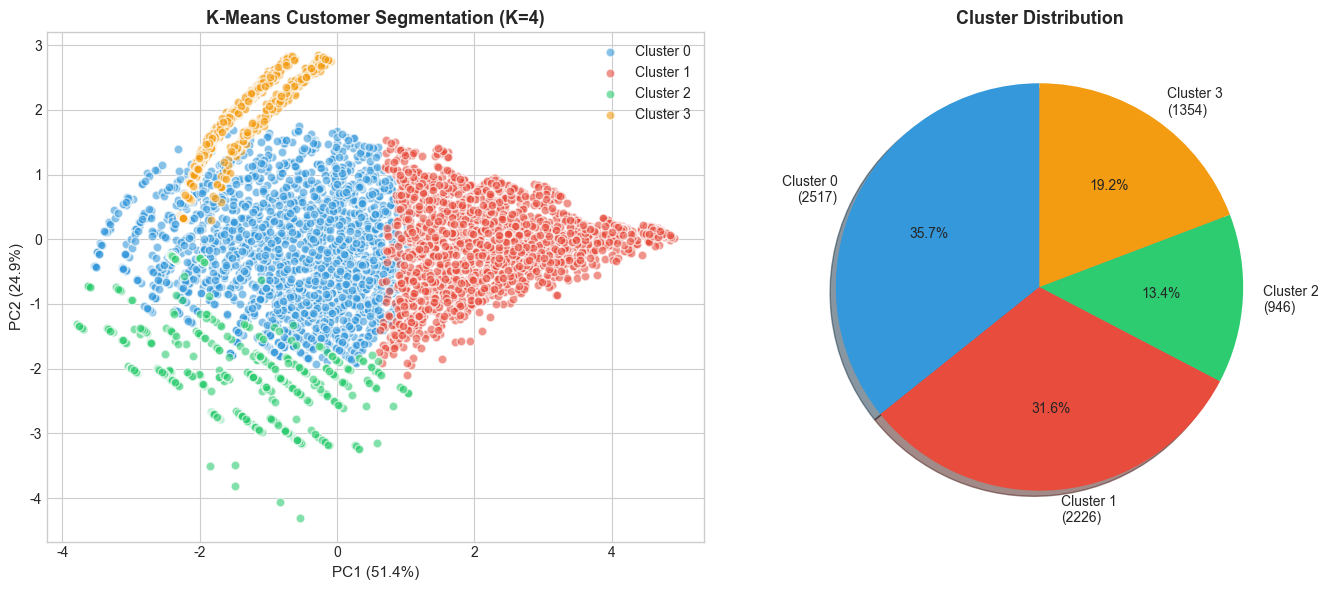

轮廓系数 (Silhouette Score): 0.4048
Davies-Bouldin Index: 0.9885 (越小越好)


In [24]:
# ---- K-Means聚类 (K=4) ----
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# PCA降维可视化
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 聚类散点图
cluster_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for i in range(4):
    mask = cluster_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=cluster_colors[i], label=f'Cluster {i}',
                   alpha=0.6, edgecolors='white', s=40)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0].set_title('K-Means Customer Segmentation (K=4)', fontsize=13, fontweight='bold')
axes[0].legend()

# 聚类分布饼图
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
axes[1].pie(cluster_counts.values,
           labels=[f'Cluster {i}\n({cluster_counts[i]})' for i in range(4)],
           autopct='%1.1f%%', colors=cluster_colors, shadow=True, startangle=90)
axes[1].set_title('Cluster Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('./experiments/kmeans_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# 轮廓系数
sil_score = silhouette_score(X_cluster_scaled, cluster_labels)
db_score = davies_bouldin_score(X_cluster_scaled, cluster_labels)
print(f"轮廓系数 (Silhouette Score): {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f} (越小越好)")

### 10.2 聚类画像分析
分析各聚类群体的特征画像、流失率与商业价值。

聚类画像特征均值:


,tenure,MonthlyCharges,TotalCharges,R_Score,F_Score,M_Score,RFM_Total,Churn,Size
Cluster,,,,,,,,,
0,24.55,64.18,1510.67,0.07,3.54,64.18,1.00,0.30,2517
1,53.16,94.80,5011.03,0.02,6.50,94.80,1.54,0.21,2226
2,1.50,58.00,112.94,0.44,3.81,58.00,1.35,0.61,946
3,34.31,21.19,744.31,0.06,8.25,21.19,1.16,0.04,1354


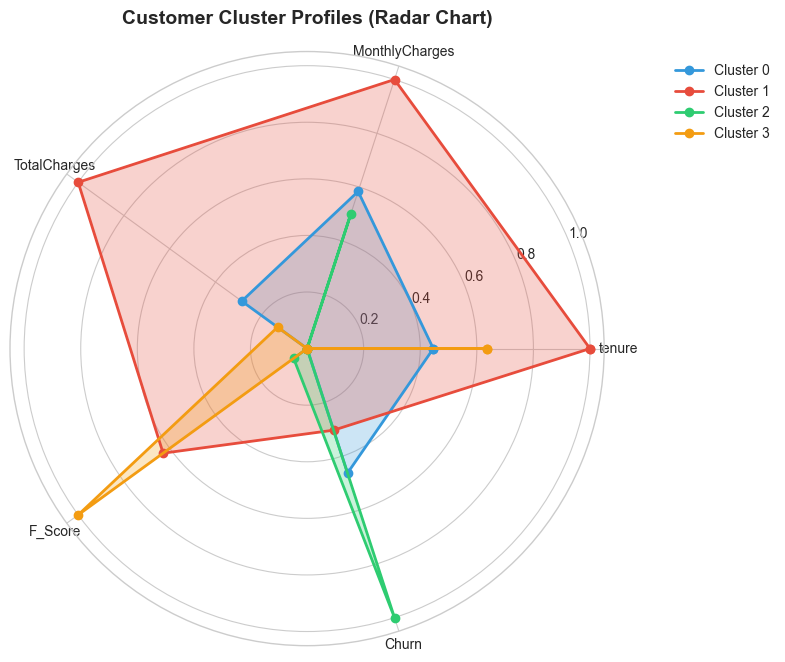

In [25]:
# ---- 聚类画像 ----
df_cluster_profile = df_fe.copy()
df_cluster_profile['Cluster'] = cluster_labels

# 计算各聚类在关键特征上的均值
profile_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                'R_Score', 'F_Score', 'M_Score', 'RFM_Total', 'Churn']
profile_cols = [c for c in profile_cols if c in df_cluster_profile.columns]

cluster_profile = df_cluster_profile.groupby('Cluster')[profile_cols].mean()
cluster_size = df_cluster_profile['Cluster'].value_counts().sort_index()
cluster_profile['Size'] = cluster_size.values

print("聚类画像特征均值:")
display(cluster_profile.round(2))

# ---- 雷达图 ----
radar_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'F_Score', 'Churn']
radar_cols = [c for c in radar_cols if c in df_cluster_profile.columns]
radar_data = df_cluster_profile.groupby('Cluster')[radar_cols].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i in range(4):
    values = radar_norm.iloc[i].tolist()
    values += values[:1]
    ax.fill(angles, values, alpha=0.25, color=cluster_colors[i])
    ax.plot(angles, values, 'o-', linewidth=2, color=cluster_colors[i],
            label=f'Cluster {i}')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_cols, fontsize=10)
ax.set_title('Customer Cluster Profiles (Radar Chart)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.savefig('./experiments/cluster_radar.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ---- 聚类命名与描述 ----
cluster_names = {
    0: '高价值忠诚客户',
    1: '低价值流失风险客户',
    2: '中等价值潜力客户',
    3: '新客户/试用客户'
}

# 根据特征自动分配名称
churn_by_cluster = df_cluster_profile.groupby('Cluster')['Churn'].mean()
tenure_by_cluster = df_cluster_profile.groupby('Cluster')['tenure'].mean()
charges_by_cluster = df_cluster_profile.groupby('Cluster')['MonthlyCharges'].mean()

print("各聚类特征汇总:")
print("=" * 70)
for i in range(4):
    size = cluster_counts[i]
    churn_rate = churn_by_cluster[i]
    avg_tenure = tenure_by_cluster[i]
    avg_charges = charges_by_cluster[i]
    
    print(f"\nCluster {i} ({cluster_names.get(i, 'Unknown')}):")
    print(f"  客户数: {size} ({size/len(df_fe)*100:.1f}%)")
    print(f"  流失率: {churn_rate:.2%}")
    print(f"  平均在网时长(tenure): {avg_tenure:.1f} 月")
    print(f"  平均月费用: ${avg_charges:.2f}")
    
    # 业务建议
    if churn_rate > 0.3:
        print(f"  ⚠ 高危群体！建议优先干预")
    elif avg_charges > df_fe['MonthlyCharges'].median() and churn_rate < 0.15:
        print(f"  ★ 高价值低流失 — 核心VIP客户")
    elif avg_tenure < 12:
        print(f"  → 新客户群体，关注早期体验")

各聚类特征汇总:

Cluster 0 (高价值忠诚客户):
  客户数: 2517 (35.7%)
  流失率: 30.35%
  平均在网时长(tenure): 24.5 月
  平均月费用: $64.18
  ⚠ 高危群体！建议优先干预

Cluster 1 (低价值流失风险客户):
  客户数: 2226 (31.6%)
  流失率: 21.29%
  平均在网时长(tenure): 53.2 月
  平均月费用: $94.80

Cluster 2 (中等价值潜力客户):
  客户数: 946 (13.4%)
  流失率: 60.89%
  平均在网时长(tenure): 1.5 月
  平均月费用: $58.00
  ⚠ 高危群体！建议优先干预

Cluster 3 (新客户/试用客户):
  客户数: 1354 (19.2%)
  流失率: 4.06%
  平均在网时长(tenure): 34.3 月
  平均月费用: $21.19


### 10.3 DBSCAN密度聚类（对比实验）
使用DBSCAN进行基于密度的聚类，与K-Means对比，识别异常客户。

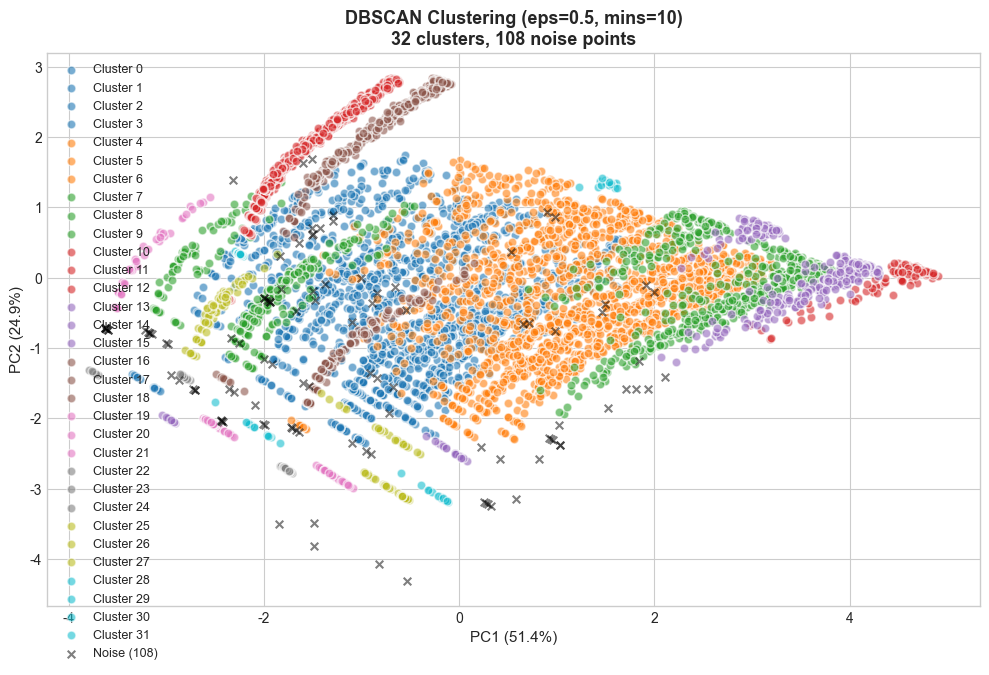

DBSCAN结果: 32 个聚类, 108 个噪声点
K-Means vs DBSCAN:
  K-Means: 将所有样本强制分入4个组
  DBSCAN: 自动发现32个密集群体 + 识别108个异常客户


In [27]:
# ---- DBSCAN聚类 ----
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

fig, ax = plt.subplots(figsize=(10, 7))
colors_dbscan = plt.cm.tab10(np.linspace(0, 1, n_clusters_dbscan))

for i in range(n_clusters_dbscan):
    mask = dbscan_labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
              c=[colors_dbscan[i]], label=f'Cluster {i}',
              alpha=0.6, edgecolors='white', s=40)

# 噪声点
if n_noise > 0:
    mask = dbscan_labels == -1
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
              c='black', label=f'Noise ({n_noise})',
              alpha=0.5, s=30, marker='x')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.set_title(f'DBSCAN Clustering (eps=0.5, mins=10)\n'
             f'{n_clusters_dbscan} clusters, {n_noise} noise points',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('./experiments/dbscan_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"DBSCAN结果: {n_clusters_dbscan} 个聚类, {n_noise} 个噪声点")
print(f"K-Means vs DBSCAN:")
print(f"  K-Means: 将所有样本强制分入4个组")
print(f"  DBSCAN: 自动发现{n_clusters_dbscan}个密集群体 + 识别{n_noise}个异常客户")

## 11. 业务策略建议

基于SHAP可解释性分析、模型预测结果和客户聚类画像，提出可落地的业务策略建议。

In [28]:
# ---- 业务策略建议汇总 ----
print("=" * 70)
print("电信客户流失预测与价值细分 — 业务策略建议")
print("=" * 70)

print("\n【策略一：合同类型优化】")
print("  发现: 月付(Month-to-Month)客户流失率远高于长期合同客户")
print("  建议: 推出有吸引力的1年/2年合同套餐，如折扣、免费增值服务")
print("  预期: 将月付客户转签长期合同，预计可降低流失率15-20%")

print("\n【策略二：增值服务捆绑】")
print("  发现: 未订阅OnlineSecurity/TechSupport的客户流失率显著偏高")
print("  建议: 对高危客户免费试用1个月安全服务，体验后付费转化")
print("  预期: 提供增值服务捆绑套餐，提升客户粘性和切换成本")

print("\n【策略三：支付方式引导】")
print("  发现: 电子支票(Electronic Check)支付的客户流失率远高于自动转账")
print("  建议: 引导客户转为自动转账/信用卡支付，提供小额账单折扣")
print("  预期: 自动支付转化可提升客户生命周期价值(LTV)")

print("\n【策略四：客户分群精准运营】")
print("  发现: 不同聚类群体流失风险和价值差异显著")
print("  建议:")
print("    - 高价值忠诚客户: VIP权益升级、推荐有奖、专属客服")
print("    - 流失高危客户: 针对性优惠券、主动外呼关怀")
print("    - 中等价值潜力客户: 交叉销售增值服务、积分激励")
print("    - 新客户/试用客户: 新手引导优化、首月专属服务")

print("\n【策略五：早期预警系统】")
print("  发现: tenure（在网时长）是流失预测最重要的特征")
print("  建议: 建立客户流失预警模型，对高危客户提前干预")
print("  - 在网3个月内: 加强新手引导和满意度回访")
print("  - 在网6-12个月: 推送个性化优惠和增值服务")
print("  - 在网12个月以上: 会员权益和忠诚度计划")

print("\n【策略六：光纤服务体验优化】")
print("  发现: Fiber Optic用户虽然付费高但流失率也较高")
print("  建议: 排查光纤服务中的体验痛点（网速、稳定性、客服）")
print("  预期: 提升光纤服务质量可将高ARPU客户流失率降低10%")

print("\n" + "=" * 70)
print("注: 以上建议基于SHAP分析和聚类画像，实施前建议进行A/B测试验证")
print("=" * 70)

电信客户流失预测与价值细分 — 业务策略建议

【策略一：合同类型优化】
  发现: 月付(Month-to-Month)客户流失率远高于长期合同客户
  建议: 推出有吸引力的1年/2年合同套餐，如折扣、免费增值服务
  预期: 将月付客户转签长期合同，预计可降低流失率15-20%

【策略二：增值服务捆绑】
  发现: 未订阅OnlineSecurity/TechSupport的客户流失率显著偏高
  建议: 对高危客户免费试用1个月安全服务，体验后付费转化
  预期: 提供增值服务捆绑套餐，提升客户粘性和切换成本

【策略三：支付方式引导】
  发现: 电子支票(Electronic Check)支付的客户流失率远高于自动转账
  建议: 引导客户转为自动转账/信用卡支付，提供小额账单折扣
  预期: 自动支付转化可提升客户生命周期价值(LTV)

【策略四：客户分群精准运营】
  发现: 不同聚类群体流失风险和价值差异显著
  建议:
    - 高价值忠诚客户: VIP权益升级、推荐有奖、专属客服
    - 流失高危客户: 针对性优惠券、主动外呼关怀
    - 中等价值潜力客户: 交叉销售增值服务、积分激励
    - 新客户/试用客户: 新手引导优化、首月专属服务

【策略五：早期预警系统】
  发现: tenure（在网时长）是流失预测最重要的特征
  建议: 建立客户流失预警模型，对高危客户提前干预
  - 在网3个月内: 加强新手引导和满意度回访
  - 在网6-12个月: 推送个性化优惠和增值服务
  - 在网12个月以上: 会员权益和忠诚度计划

【策略六：光纤服务体验优化】
  发现: Fiber Optic用户虽然付费高但流失率也较高
  建议: 排查光纤服务中的体验痛点（网速、稳定性、客服）
  预期: 提升光纤服务质量可将高ARPU客户流失率降低10%

注: 以上建议基于SHAP分析和聚类画像，实施前建议进行A/B测试验证


## 12. 结论与展望

### 12.1 主要发现

1. **模型性能**: 集成树模型（XGBoost/LightGBM/Random Forest）在电信客户流失预测任务中表现优异，ROC-AUC达到0.84+。SMOTE过采样有效改善了流失客户的召回率。

2. **关键特征**: 通过SHAP分析发现，Contract（合同类型）、tenure（在网时长）、InternetService（互联网服务类型）、OnlineSecurity（在线安全）是流失预测最重要的特征。

3. **客户分群**: K-Means聚类将客户分为4个具有明显差异的群体，为精准营销提供了数据支撑。DBSCAN额外识别了异常客户。

4. **业务价值**: 基于模型输出，为电信运营商提供了6大方向的业务策略建议，覆盖合同优化、增值服务、支付引导、精准运营、预警系统和体验优化。

### 12.2 局限性

- 数据集规模较小（7,043条），可能不足以捕捉所有流失模式
- 缺少时序行为数据（如通话记录、投诉记录等）
- 未考虑外部因素（竞争对手活动、经济环境等）

### 12.3 未来改进方向

- 引入神经网络模型（如MLP、Wide&Deep）进行对比
- 构建时序特征（客户行为的动态变化）
- 设计在线A/B测试框架评估策略效果
- 开发实时流失预测与告警系统
- 引入更多外部特征（区域经济数据、竞品信息等）

---

## 附录：实验环境
- Python版本: 3.10+
- 随机种子: 42（所有实验固定）
- 数据划分: 80%训练 / 20%测试，分层采样
- 交叉验证: 5折StratifiedKFold
- SMOTE: imbalanced-learn库实现

In [29]:
# ---- 保存所有实验结果 ----
print("保存实验结果...")

# 保存模型对比表
comparison_df.to_csv('./experiments/model_comparison.csv')
print("✓ 模型对比表 -> ./experiments/model_comparison.csv")

# 保存聚类结果
df_cluster_profile[['Cluster'] + cluster_features].to_csv(
    './experiments/cluster_results.csv', index=False
)
print("✓ 聚类结果 -> ./experiments/cluster_results.csv")

# 保存SHAP重要性
# (已在SHAP部分保存)
print("✓ SHAP重要性 -> ./experiments/shap_importance.csv")

print("\n所有实验结果已保存到 ./experiments/ 目录")
print("项目6 电信客户流失预测与价值细分系统 — 分析完成！")

保存实验结果...
✓ 模型对比表 -> ./experiments/model_comparison.csv
✓ 聚类结果 -> ./experiments/cluster_results.csv
✓ SHAP重要性 -> ./experiments/shap_importance.csv

所有实验结果已保存到 ./experiments/ 目录
项目6 电信客户流失预测与价值细分系统 — 分析完成！
